In [1]:
import tensorflow as tf
import tensorflow_hub as hub

In [2]:
import tensorflow as tf
from tensorflow.keras import layers

In [3]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1,1,1,1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

In [4]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=tf.shape(patch)[1], delta=1)
        return self.projection(patch) + self.position_embedding(positions)

In [5]:
input_shape = (224,224,3)
patch_size = 16
projection_dim = 64
num_heads = 4
transformer_layers = 4
mlp_head_units = [128,64]

inputs = layers.Input(shape=input_shape)

# create patches
patches = Patches(patch_size)(inputs)

num_patches = (224 // patch_size) ** 2

# encode patches
encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

# transformer blocks
for _ in range(transformer_layers):
    x1 = layers.LayerNormalization()(encoded_patches)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim
    )(x1, x1)
    x2 = layers.Add()([attention_output, encoded_patches])
    x3 = layers.LayerNormalization()(x2)

    x3 = layers.Dense(projection_dim*2, activation="gelu")(x3)
    x3 = layers.Dense(projection_dim)(x3)

    encoded_patches = layers.Add()([x3, x2])

# classification head
representation = layers.LayerNormalization()(encoded_patches)
representation = layers.GlobalAveragePooling1D()(representation)

for units in mlp_head_units:
    representation = layers.Dense(units, activation="relu")(representation)
    representation = layers.Dropout(0.3)(representation)

outputs = layers.Dense(8, activation="softmax")(representation)

model_vit = tf.keras.Model(inputs, outputs)

In [6]:
model_vit.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [8]:
train_data = datagen.flow_from_directory(
    "Padded_imgs",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 7576 images belonging to 8 classes.


In [9]:
test_data = datagen.flow_from_directory(
    "Padded_imgs",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 1891 images belonging to 8 classes.


In [10]:
print(train_data.class_indices)
print("Number of classes:", len(train_data.class_indices))

{'2S1': 0, 'BRDM_2': 1, 'BTR_60': 2, 'D7': 3, 'SLICY': 4, 'T62': 5, 'ZIL131': 6, 'ZSU_23_4': 7}
Number of classes: 8


In [23]:
import shutil
import os

checkpoint_path = "Padded_imgs/.ipynb_checkpoints"

if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)
    print("✅ Removed checkpoints")
else:
    print("No checkpoints folder found")

✅ Removed checkpoints


In [11]:
history = model_vit.fit(
    train_data,
    epochs=20,
    validation_data=test_data
)

Epoch 1/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 152s 619ms/step - accuracy: 0.2562 - loss: 1.8964 - val_accuracy: 0.2559 - val_loss: 1.8415
Epoch 2/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 56s 238ms/step - accuracy: 0.4009 - loss: 1.5567 - val_accuracy: 0.6071 - val_loss: 1.2102
Epoch 3/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 56s 237ms/step - accuracy: 0.6859 - loss: 0.8852 - val_accuracy: 0.8012 - val_loss: 0.5207
Epoch 4/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 58s 246ms/step - accuracy: 0.8182 - loss: 0.4646 - val_accuracy: 0.8937 - val_loss: 0.2728
Epoch 5/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 57s 239ms/step - accuracy: 0.8553 - loss: 0.3498 - val_accuracy: 0.8689 - val_loss: 0.3332
Epoch 6/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 65s 276ms/step - accuracy: 0.8643 - loss: 0.3230 - val_accuracy: 0.8916 - val_loss: 0.2454
Epoch 7/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 87s 298ms/step - accuracy: 0.8800 - loss: 0.2759 - val_accuracy: 0.9069 - val_loss: 0.2248
Epoch 8/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 75s 317ms/step - accuracy: 0.9032 - loss: 

In [12]:
val_loss, val_acc = model_vit.evaluate(test_data)
print("ViT Validation Accuracy:", val_acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.9455 - loss: 0.1889
ViT Validation Accuracy: 0.9455314874649048


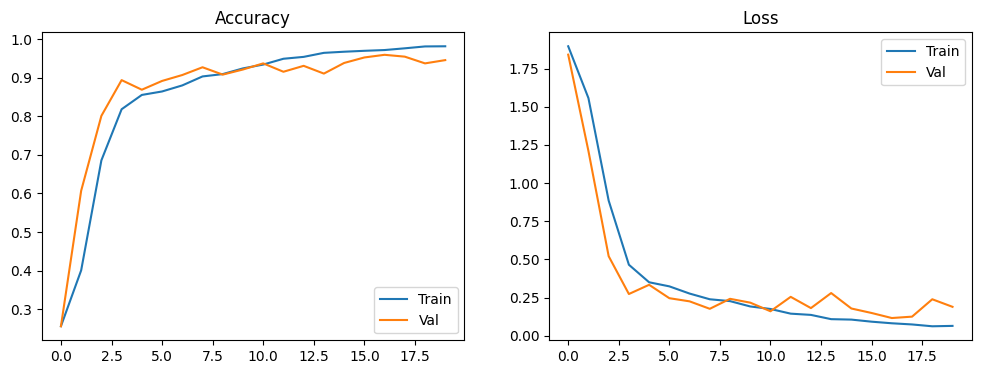

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Val"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Val"])

plt.show()

In [15]:
predictions = model_vit.predict(test_data)

60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step


In [16]:
true_labels = test_data.classes
class_names = list(test_data.class_indices.keys())

In [17]:
import numpy as np

for i in range(5):
    pred_class = class_names[np.argmax(predictions[i])]
    actual_class = class_names[true_labels[i]]
    
    print("Predicted:", pred_class, "| Actual:", actual_class)

Predicted: ZIL131 | Actual: 2S1
Predicted: ZIL131 | Actual: 2S1
Predicted: ZSU_23_4 | Actual: 2S1
Predicted: T62 | Actual: 2S1
Predicted: SLICY | Actual: 2S1


In [18]:
model_vit.save("vit_mstar_model.keras")
